# Setup E - PAT Rig NIR Effective Sample Size Using Swept Capsule Geometry

Level-controlled vertical PAT rig with a side-window non-contact NIR probe, using a unique-exposure capsule footprint as the primary effective sample size proxy.


## Background

Setup E models a PAT (Process Analytical Technology) rig as a vertical cylindrical sampling interface fed continuously from an upstream manufacturing unit. A rotating outlet valve at the bottom controls discharge, while level sensors along the wall maintain the rig at approximately half full during operation.

The primary NIR instrument views the powder through a side optical window positioned near the lower part of the rig. In the base case used here, the measurement location is one-quarter of the rig height above the bottom outlet and the non-contact NIR spot diameter is 25 mm.

At the start of a spectral acquisition, all powder inside the circular NIR footprint contributes to the measured spectrum. During the acquisition, powder motion translates new material into the beam. Because the Setup E NIR spot is large relative to the powder advance during a 1 s acquisition, the effective sample size should include both the initial circular footprint and the additional swept-in material. The primary proxy in this notebook therefore represents the unique exposed powder as a rounded-end capsule footprint multiplied by optical penetration depth.


## Objective

Compute three Setup E sampling quantities:

1. instantaneous probed mass at acquisition start
2. unique exposed effective sample size using swept capsule geometry
3. time-weighted contribution proxy retained as a future research quantity

The analysis sweeps bulk density, penetration depth, acquisition time, and throughput while keeping the covered-probe PAT rig geometry and 25 mm NIR spot fixed.


## Theory

### Covered-Probe PAT Rig Geometry

The PAT rig is represented as a vertical cylindrical flow region observed through a side optical window. The operating assumption is that level control keeps the probe window buried in powder during normal operation, so probe coverage is treated as guaranteed.

### Throughput-Derived Powder Velocity

Powder motion near the covered probe is approximated as a first-order dense moving column. The local axial velocity is estimated from throughput and the full cylindrical cross-section:

$$
v = \frac{\dot{m}}{\rho_{bulk} \cdot A_{pipe}}
$$

where

$$
A_{pipe} = \pi \left(\frac{D_{pipe}}{2}\right)^2
$$

This is a simplifying assumption. It ignores wall slip, local recirculation, outlet-valve kinematics, and nonuniform velocity profiles near the probe.

### Quantity 1: Instantaneous Probed Mass

The non-contact NIR spot is represented as a circular optical footprint:

$$
A_{spot} = \pi \left(\frac{D_{spot}}{2}\right)^2
$$

The instantaneous probed mass at acquisition start is:

$$
m_{inst} = \rho_{bulk} \cdot A_{spot} \cdot d_{pen}
$$

### Quantity 2: Unique Exposed Effective Sample Size

During an acquisition of length $T_{acq}$, powder advances by:

$$
\Delta z = v \cdot T_{acq}
$$

The unique footprint exposed at least once is approximated as a swept capsule: the initial circular spot plus a rectangular swept increment of width $D_{spot}$ and length $\Delta z$:

$$
A_{unique} = A_{spot} + D_{spot} \cdot \Delta z
$$

The primary effective sample size proxy is therefore:

$$
m_{unique} = \rho_{bulk} \cdot A_{unique} \cdot d_{pen}
$$

This proxy counts unique material exposed at least once. It does not weight by residence time or optical intensity.

### Quantity 3: Time-Weighted Contribution Proxy

A measured NIR spectrum is time-integrated, so material that remains in the beam longer can contribute more strongly than material briefly entering near an edge. This notebook retains a simple mass-time proxy:

$$
m_{time} = m_{inst} \cdot T_{acq}
$$

This is retained for future research only. It is not the primary effective sample size in this notebook.

### Related Diagnostic: Mass Passed the NIR Footprint

The mass passed diagnostic is:

$$
m_{pass} = \rho_{bulk} \cdot A_{spot} \cdot v \cdot T_{acq}
$$

This quantity is useful as a transport reference, but it should not be interpreted as the optical effective sample size because it does not include penetration-depth reduction.


## Interpreting Density, Velocity, and Throughput

At fixed mass throughput, the local powder velocity in this model is inversely proportional to bulk density:

$$
v = \frac{\dot{m}}{\rho_{bulk} \cdot A_{pipe}}
$$

For the same throughput and PAT rig cross-section, lower bulk-density powder occupies a larger volumetric flow rate and therefore moves faster past the probe. Higher bulk-density powder moves more slowly.

This has two consequences in the capsule model:

1. Increasing bulk density increases the instantaneous mass in the initial circular NIR footprint.
2. Increasing bulk density decreases the powder advance during acquisition, which reduces the swept-in incremental contribution.

Unlike a pure renewal-count proxy, density does not fully cancel in the primary Setup E effective sample size because the initial circular footprint is always included.


## Three Sampling Quantities Used in This Notebook

This notebook separates three related but distinct quantities:

1. **Instantaneous probed mass**: material inside the circular NIR footprint at acquisition start.
2. **Unique exposed effective sample size**: all material exposed at least once during acquisition, represented by the swept capsule footprint.
3. **Time-weighted contribution proxy**: a simple mass-time exposure proxy retained for future research.

The unique exposed effective sample size is the primary reported ESS in this notebook. The time-weighted proxy should not be interpreted as the primary ESS.


## Assumptions

- vertical cylindrical PAT rig with top feed and bottom discharge through a rotating outlet valve
- the operating window is controlled so the probe window remains continuously covered during normal operation
- no explicit level-control dynamics are modeled because probe coverage is treated as guaranteed by design
- the powder near the probe is treated as a dense moving column
- powder velocity at the probe is approximated from throughput and full pipe cross-section
- the NIR spot is circular and viewed through a side optical window
- powder motion during one acquisition is represented as linear translation across the spot
- the unique exposed footprint is represented as a swept capsule: initial circle plus rectangular extension
- measurement depth is uniform over the full exposed capsule footprint
- the capsule model counts material exposed at least once, regardless of how long it remains inside the beam
- no explicit outlet-valve kinematics, turbulence, segregation, recirculation, or wall-slip correction
- no detailed radiative-transfer model or optical intensity weighting is included


## Input Parameters

Baseline covered-probe PAT rig configuration:

- pipe diameter: 10.0 cm (100 mm)
- NIR spot diameter: 2.5 cm (25 mm)
- base-case measurement depth: 0.1 cm (1.0 mm)
- base-case bulk density: 0.5 g/cm$^3$
- density scenarios: 0.4, 0.5, and 0.6 g/cm$^3$
- base-case throughput: 95 kg/h
- base-case acquisition time: 1.0 s

Sweeps:

- bulk density scenarios: 0.4, 0.5, and 0.6 g/cm$^3$
- penetration depth: 0.1 mm to 2.0 mm in 0.1 mm steps for each bulk-density scenario
- acquisition time: 1.0 s to 5.0 s with 20 points for each bulk-density scenario
- throughput-acquisition sweep: 10 to 100 kg/h x 1.0 to 5.0 s x bulk-density scenarios

Internal calculations use CGS units, so penetration depth is computed in cm even when plotted in mm.


In [1]:
import math
from dataclasses import dataclass
from typing import Iterable, Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
@dataclass(frozen=True)
class BaseParams:
    # Geometry
    pipe_diameter_cm: float = 10.0
    nir_spot_diameter_cm: float = 2.5
    measurement_depth_cm: float = 0.1  # base case: 1 mm = 0.1 cm

    # Material
    bulk_density_g_per_cm3: float = 0.5

    # Throughput (mass flow on a 3600 s basis)
    throughput_kg: float = 95.0
    throughput_time_s: float = 60.0 * 60.0

    # If set, overrides velocity derived from throughput (units: cm/s)
    velocity_override_cm_s: Optional[float] = None

    # Spectral acquisition time (seconds)
    acquisition_time_s: float = 1.0


density_scenarios = [0.4, 0.5, 0.6]
base = BaseParams()

input_summary_df = pd.DataFrame(
    {
        "parameter": [
            "pipe_diameter_cm",
            "nir_spot_diameter_cm",
            "measurement_depth_cm",
            "bulk_density_g_per_cm3",
            "density_scenarios_g_per_cm3",
            "throughput_kg",
            "throughput_time_s",
            "acquisition_time_s",
            "primary_ess_proxy",
        ],
        "value": [
            base.pipe_diameter_cm,
            base.nir_spot_diameter_cm,
            base.measurement_depth_cm,
            base.bulk_density_g_per_cm3,
            ", ".join(f"{density:.1f}" for density in density_scenarios),
            base.throughput_kg,
            base.throughput_time_s,
            base.acquisition_time_s,
            "unique exposed swept capsule mass",
        ],
    }
)

input_summary_df


,parameter,value
0,pipe_diameter_cm,10.0
1,nir_spot_diameter_cm,2.5
2,measurement_depth_cm,0.1
3,bulk_density_g_per_cm3,0.5
4,density_scenarios_g_per_cm3,"0.4, 0.5, 0.6"
5,throughput_kg,95.0
6,throughput_time_s,3600.0
7,acquisition_time_s,1.0
8,primary_ess_proxy,unique exposed swept capsule mass


In [3]:
def area_circle_cm2(d_cm: float) -> float:
    if d_cm <= 0:
        raise ValueError("d_cm must be > 0")
    r = d_cm / 2.0
    return math.pi * r * r


def swept_capsule_area_cm2(spot_diameter_cm: float, advance_cm: float) -> float:
    if spot_diameter_cm <= 0:
        raise ValueError("spot_diameter_cm must be > 0")
    if advance_cm < 0:
        raise ValueError("advance_cm must be >= 0")
    return area_circle_cm2(spot_diameter_cm) + spot_diameter_cm * advance_cm


def throughput_to_velocity_cm_s(
    pipe_diameter_cm: float,
    bulk_density_g_per_cm3: float,
    throughput_kg: float,
    throughput_time_s: float,
) -> float:
    if pipe_diameter_cm <= 0:
        raise ValueError("pipe_diameter_cm must be > 0")
    if bulk_density_g_per_cm3 <= 0:
        raise ValueError("bulk_density_g_per_cm3 must be > 0")
    if throughput_kg < 0:
        raise ValueError("throughput_kg must be >= 0")
    if throughput_time_s <= 0:
        raise ValueError("throughput_time_s must be > 0")

    mdot_g_s = (throughput_kg * 1000.0) / throughput_time_s
    vdot_cm3_s = mdot_g_s / bulk_density_g_per_cm3
    A_pipe_cm2 = area_circle_cm2(pipe_diameter_cm)
    return vdot_cm3_s / A_pipe_cm2


def compute_metrics(params: BaseParams) -> Dict[str, float]:
    if params.measurement_depth_cm <= 0:
        raise ValueError("measurement_depth_cm must be > 0")
    if params.acquisition_time_s <= 0:
        raise ValueError("acquisition_time_s must be > 0")

    A_pipe_cm2 = area_circle_cm2(params.pipe_diameter_cm)
    A_spot_cm2 = area_circle_cm2(params.nir_spot_diameter_cm)

    if params.velocity_override_cm_s is None:
        v_cm_s = throughput_to_velocity_cm_s(
            pipe_diameter_cm=params.pipe_diameter_cm,
            bulk_density_g_per_cm3=params.bulk_density_g_per_cm3,
            throughput_kg=params.throughput_kg,
            throughput_time_s=params.throughput_time_s,
        )
        velocity_source = "derived_from_throughput"
    else:
        if params.velocity_override_cm_s < 0:
            raise ValueError("velocity_override_cm_s must be >= 0")
        v_cm_s = params.velocity_override_cm_s
        velocity_source = "user_override"

    dz_cm = v_cm_s * params.acquisition_time_s
    swept_increment_area_cm2 = params.nir_spot_diameter_cm * dz_cm
    unique_exposed_area_cm2 = swept_capsule_area_cm2(params.nir_spot_diameter_cm, dz_cm)

    probe_volume_cm3 = A_spot_cm2 * params.measurement_depth_cm
    probe_mass_g_instant = probe_volume_cm3 * params.bulk_density_g_per_cm3

    swept_increment_volume_cm3 = swept_increment_area_cm2 * params.measurement_depth_cm
    unique_exposed_volume_cm3 = unique_exposed_area_cm2 * params.measurement_depth_cm
    swept_increment_mass_g = swept_increment_volume_cm3 * params.bulk_density_g_per_cm3
    unique_exposed_mass_g = unique_exposed_volume_cm3 * params.bulk_density_g_per_cm3

    mass_passed_g_per_acq = (
        params.bulk_density_g_per_cm3 * A_spot_cm2 * v_cm_s * params.acquisition_time_s
    )

    time_weighted_contribution_g_s = probe_mass_g_instant * params.acquisition_time_s

    mdot_g_s = (params.throughput_kg * 1000.0) / params.throughput_time_s
    vdot_cm3_s = mdot_g_s / params.bulk_density_g_per_cm3

    return {
        "setup": "E",
        "pipe_diameter_cm": params.pipe_diameter_cm,
        "pipe_area_cm2": A_pipe_cm2,
        "nir_spot_diameter_cm": params.nir_spot_diameter_cm,
        "nir_spot_area_cm2": A_spot_cm2,
        "spot_area_cm2": A_spot_cm2,
        "measurement_depth_cm": params.measurement_depth_cm,
        "measurement_depth_mm": params.measurement_depth_cm * 10.0,
        "bulk_density_g_per_cm3": params.bulk_density_g_per_cm3,
        "bulk_density_label": f"{params.bulk_density_g_per_cm3:.1f} g/cm^3",
        "throughput_kg": params.throughput_kg,
        "throughput_time_s": params.throughput_time_s,
        "mass_flow_g_s": mdot_g_s,
        "vol_flow_cm3_s": vdot_cm3_s,
        "velocity_source": velocity_source,
        "velocity_cm_s": v_cm_s,
        "velocity_mm_s": v_cm_s * 10.0,
        "acquisition_time_s": params.acquisition_time_s,
        "advance_dz_cm_per_acq": dz_cm,
        "advance_dz_mm_per_acq": dz_cm * 10.0,
        "advance_to_spot_diameter_ratio": dz_cm / params.nir_spot_diameter_cm,
        "swept_increment_area_cm2": swept_increment_area_cm2,
        "unique_exposed_area_cm2": unique_exposed_area_cm2,
        "probe_volume_cm3": probe_volume_cm3,
        "probe_volume_cm3_instant": probe_volume_cm3,
        "swept_increment_volume_cm3": swept_increment_volume_cm3,
        "unique_exposed_volume_cm3": unique_exposed_volume_cm3,
        "probe_mass_g_instant": probe_mass_g_instant,
        "probe_mass_mg_instant": probe_mass_g_instant * 1000.0,
        "swept_increment_mass_g": swept_increment_mass_g,
        "swept_increment_mass_mg": swept_increment_mass_g * 1000.0,
        "unique_exposed_mass_g": unique_exposed_mass_g,
        "unique_exposed_mass_mg": unique_exposed_mass_g * 1000.0,
        "effective_sample_size_mg": unique_exposed_mass_g * 1000.0,
        "mass_passed_g_per_acq": mass_passed_g_per_acq,
        "mass_passed_mg_per_acq": mass_passed_g_per_acq * 1000.0,
        "mass_time_exposure_g_s": time_weighted_contribution_g_s,
        "mass_time_exposure_mg_s": time_weighted_contribution_g_s * 1000.0,
        "time_weighted_contribution_proxy_g_s": time_weighted_contribution_g_s,
        "time_weighted_contribution_proxy_mg_s": time_weighted_contribution_g_s * 1000.0,
        "effective_sample_size_basis": "unique_exposed_swept_capsule_mass",
    }


In [4]:
def linspace_list(start: float, stop: float, n: int) -> List[float]:
    if n < 2:
        return [float(start)]
    return list(np.linspace(start, stop, n))


def run_sweep(base: BaseParams, sweep: Dict[str, Iterable[float]]) -> pd.DataFrame:
    base_fields = set(base.__dataclass_fields__.keys())
    for k in sweep.keys():
        if k not in base_fields:
            raise KeyError(f"Unknown BaseParams field in sweep: '{k}'")

    keys = list(sweep.keys())
    values = [list(sweep[k]) for k in keys]
    grids = np.meshgrid(*values, indexing="ij")
    combos = np.stack([g.ravel() for g in grids], axis=1)

    rows: List[Dict[str, float]] = []
    for combo in combos:
        kwargs = {k: float(v) for k, v in zip(keys, combo)}
        p = BaseParams(**{**base.__dict__, **kwargs})
        rows.append(compute_metrics(p))

    return pd.DataFrame(rows)


## Compute Sampling Metrics

Run a discrete bulk-density comparison together with a penetration-depth sweep by density, an acquisition-time sweep by density, and a throughput-acquisition-time sweep by density. The primary effective sample size is the unique exposed mass from the swept capsule footprint.


In [5]:
penetration_depths_cm = [i / 100.0 for i in range(1, 21)]  # 0.01 to 0.20 cm = 0.1 to 2.0 mm

sweep_density = {"bulk_density_g_per_cm3": density_scenarios}
df_density = run_sweep(base, sweep_density)
df_density["sweep_type"] = "density"

sweep_penetration_density = {
    "bulk_density_g_per_cm3": density_scenarios,
    "measurement_depth_cm": penetration_depths_cm,
}
df_penetration_density = run_sweep(base, sweep_penetration_density)
df_penetration_density["sweep_type"] = "penetration_depth_density"

sweep_acq_density = {
    "bulk_density_g_per_cm3": density_scenarios,
    "acquisition_time_s": linspace_list(1.0, 5.0, 20),
}
df_acq_density = run_sweep(base, sweep_acq_density)
df_acq_density["sweep_type"] = "acquisition_time_density"

sweep_3d = {
    "bulk_density_g_per_cm3": density_scenarios,
    "throughput_kg": linspace_list(10, 100, 20),
    "acquisition_time_s": linspace_list(1.0, 5.0, 20),
}
df_3d = run_sweep(base, sweep_3d)
df_3d["sweep_type"] = "throughput_acquisition_density"

results_df = pd.concat([df_density, df_penetration_density, df_acq_density, df_3d], ignore_index=True)

results_df.head(10)


,setup,pipe_diameter_cm,pipe_area_cm2,nir_spot_diameter_cm,nir_spot_area_cm2,spot_area_cm2,measurement_depth_cm,measurement_depth_mm,bulk_density_g_per_cm3,bulk_density_label,...,unique_exposed_mass_mg,effective_sample_size_mg,mass_passed_g_per_acq,mass_passed_mg_per_acq,mass_time_exposure_g_s,mass_time_exposure_mg_s,time_weighted_contribution_proxy_g_s,time_weighted_contribution_proxy_mg_s,effective_sample_size_basis,sweep_type
0,E,10.0,78.539816,2.5,4.908739,4.908739,0.10,1.0,0.4,0.4 g/cm^3,...,280.347983,280.347983,1.649306,1649.305556,0.196350,196.349541,0.196350,196.349541,unique_exposed_swept_capsule_mass,density
1,E,10.0,78.539816,2.5,4.908739,4.908739,0.10,1.0,0.5,0.5 g/cm^3,...,329.435368,329.435368,1.649306,1649.305556,0.245437,245.436926,0.245437,245.436926,unique_exposed_swept_capsule_mass,density
2,E,10.0,78.539816,2.5,4.908739,4.908739,0.10,1.0,0.6,0.6 g/cm^3,...,378.522753,378.522753,1.649306,1649.305556,0.294524,294.524311,0.294524,294.524311,unique_exposed_swept_capsule_mass,density
3,E,10.0,78.539816,2.5,4.908739,4.908739,0.01,0.1,0.4,0.4 g/cm^3,...,28.034798,28.034798,1.649306,1649.305556,0.019635,19.634954,0.019635,19.634954,unique_exposed_swept_capsule_mass,penetration_depth_density
4,E,10.0,78.539816,2.5,4.908739,4.908739,0.02,0.2,0.4,0.4 g/cm^3,...,56.069597,56.069597,1.649306,1649.305556,0.039270,39.269908,0.039270,39.269908,unique_exposed_swept_capsule_mass,penetration_depth_density
5,E,10.0,78.539816,2.5,4.908739,4.908739,0.03,0.3,0.4,0.4 g/cm^3,...,84.104395,84.104395,1.649306,1649.305556,0.058905,58.904862,0.058905,58.904862,unique_exposed_swept_capsule_mass,penetration_depth_density
6,E,10.0,78.539816,2.5,4.908739,4.908739,0.04,0.4,0.4,0.4 g/cm^3,...,112.139193,112.139193,1.649306,1649.305556,0.078540,78.539816,0.078540,78.539816,unique_exposed_swept_capsule_mass,penetration_depth_density
7,E,10.0,78.539816,2.5,4.908739,4.908739,0.05,0.5,0.4,0.4 g/cm^3,...,140.173992,140.173992,1.649306,1649.305556,0.098175,98.174770,0.098175,98.174770,unique_exposed_swept_capsule_mass,penetration_depth_density
8,E,10.0,78.539816,2.5,4.908739,4.908739,0.06,0.6,0.4,0.4 g/cm^3,...,168.208790,168.208790,1.649306,1649.305556,0.117810,117.809725,0.117810,117.809725,unique_exposed_swept_capsule_mass,penetration_depth_density
9,E,10.0,78.539816,2.5,4.908739,4.908739,0.07,0.7,0.4,0.4 g/cm^3,...,196.243588,196.243588,1.649306,1649.305556,0.137445,137.444679,0.137445,137.444679,unique_exposed_swept_capsule_mass,penetration_depth_density


## Interpretation of the Simulation Table

Each row corresponds to one combination of operating parameters. Key columns:

- **probe_mass_mg_instant**: mass inside the circular NIR spot at acquisition start
- **advance_dz_mm_per_acq**: powder travel distance during one acquisition
- **swept_increment_mass_mg**: additional unique mass entering the NIR footprint during acquisition
- **unique_exposed_mass_mg**: instantaneous mass plus swept-in unique mass
- **effective_sample_size_mg**: primary ESS proxy, equal to unique exposed capsule mass
- **mass_passed_mg_per_acq**: transport diagnostic for mass crossing the full NIR spot footprint, not the primary ESS
- **time_weighted_contribution_proxy_mg_s**: future-research mass-time proxy, not the primary ESS

Because the 25 mm NIR spot is large relative to base-case powder advance, the instantaneous circular footprint remains a major part of the primary effective sample size.


In [6]:
base_metrics = compute_metrics(base)
baseline_keys = [
    "bulk_density_g_per_cm3",
    "measurement_depth_cm",
    "measurement_depth_mm",
    "nir_spot_diameter_cm",
    "velocity_mm_s",
    "acquisition_time_s",
    "advance_dz_mm_per_acq",
    "probe_mass_mg_instant",
    "swept_increment_mass_mg",
    "unique_exposed_mass_mg",
    "effective_sample_size_mg",
    "mass_passed_mg_per_acq",
    "time_weighted_contribution_proxy_mg_s",
]
baseline_display = pd.DataFrame(
    [{"metric": key, "value": f"{base_metrics[key]:.6g}"} for key in baseline_keys]
)

baseline_display


,metric,value
0,bulk_density_g_per_cm3,0.5
1,measurement_depth_cm,0.1
2,measurement_depth_mm,1
3,nir_spot_diameter_cm,2.5
4,velocity_mm_s,6.71988
5,acquisition_time_s,1
6,advance_dz_mm_per_acq,6.71988
7,probe_mass_mg_instant,245.437
8,swept_increment_mass_mg,83.9984
9,unique_exposed_mass_mg,329.435


## Plot 1: Instantaneous, Swept-In, and Unique Exposed Mass vs Penetration Depth

This plot shows how the initial circular contribution, the swept-in incremental contribution, and the primary effective sample size scale with penetration depth for the base bulk-density scenario.


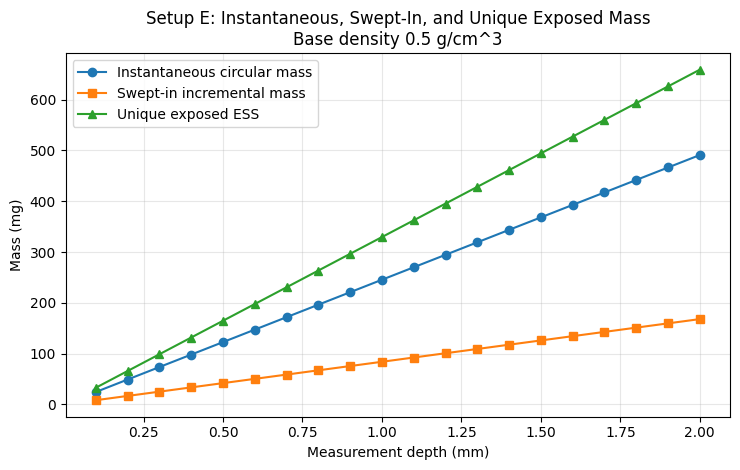

In [7]:
df_pen_sorted = df_penetration_density.sort_values(["bulk_density_g_per_cm3", "measurement_depth_cm"]).copy()
df_pen_sorted["measurement_depth_mm"] = df_pen_sorted["measurement_depth_cm"] * 10.0
base_density_pen = df_pen_sorted[df_pen_sorted["bulk_density_g_per_cm3"] == base.bulk_density_g_per_cm3]

fig_instant_swept_unique_vs_depth, ax = plt.subplots(figsize=(7.5, 4.8))
ax.plot(base_density_pen["measurement_depth_mm"], base_density_pen["probe_mass_mg_instant"], marker="o", label="Instantaneous circular mass")
ax.plot(base_density_pen["measurement_depth_mm"], base_density_pen["swept_increment_mass_mg"], marker="s", label="Swept-in incremental mass")
ax.plot(base_density_pen["measurement_depth_mm"], base_density_pen["effective_sample_size_mg"], marker="^", label="Unique exposed ESS")
ax.set_xlabel("Measurement depth (mm)")
ax.set_ylabel("Mass (mg)")
ax.set_title("Setup E: Instantaneous, Swept-In, and Unique Exposed Mass\nBase density 0.5 g/cm^3")
ax.grid(True, alpha=0.3)
ax.legend()
fig_instant_swept_unique_vs_depth.tight_layout()
plt.show()


## Plot 2: Effective Sample Size vs Penetration Depth by Density

Shows how the swept-capsule effective sample size changes as the assumed NIR penetration depth increases from 0.1 mm to 2.0 mm for bulk densities of 0.4, 0.5, and 0.6 g/cm$^3$.


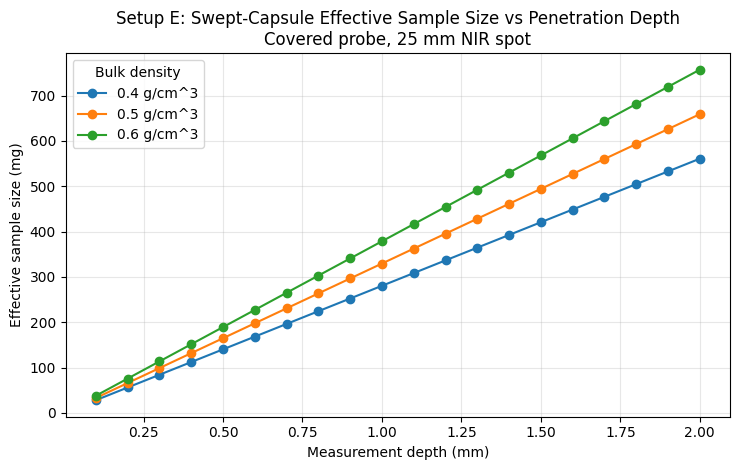

In [8]:
fig_eff_sample_vs_depth, ax = plt.subplots(figsize=(7.5, 4.8))
for density, group in df_pen_sorted.groupby("bulk_density_g_per_cm3"):
    ax.plot(group["measurement_depth_mm"], group["effective_sample_size_mg"], marker="o", label=f"{density:.1f} g/cm^3")
ax.set_xlabel("Measurement depth (mm)")
ax.set_ylabel("Effective sample size (mg)")
ax.set_title("Setup E: Swept-Capsule Effective Sample Size vs Penetration Depth\nCovered probe, 25 mm NIR spot")
ax.grid(True, alpha=0.3)
ax.legend(title="Bulk density")
fig_eff_sample_vs_depth.tight_layout()
plt.show()


## Plot 3: Powder Advance During Acquisition vs Acquisition Time

This plot shows the distance powder advances during one acquisition. In the capsule geometry, this advance elongates the exposed NIR footprint.


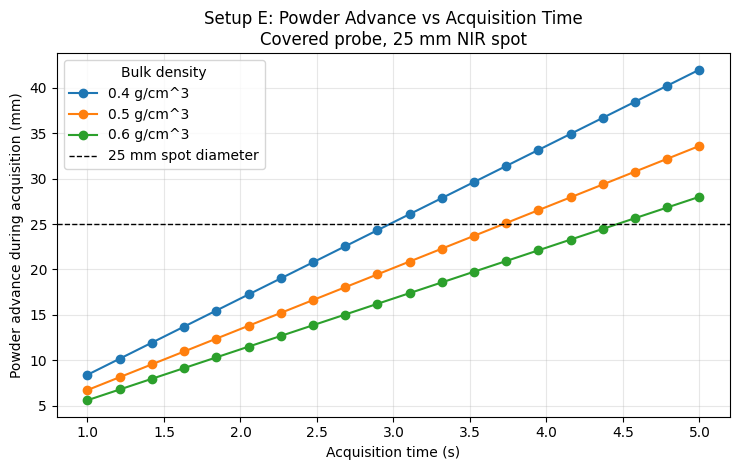

In [9]:
df_acq_sorted = df_acq_density.sort_values(["bulk_density_g_per_cm3", "acquisition_time_s"]).copy()

fig_advance_vs_time, ax = plt.subplots(figsize=(7.5, 4.8))
for density, group in df_acq_sorted.groupby("bulk_density_g_per_cm3"):
    ax.plot(group["acquisition_time_s"], group["advance_dz_mm_per_acq"], marker="o", label=f"{density:.1f} g/cm^3")
ax.axhline(base.nir_spot_diameter_cm * 10.0, color="black", linestyle="--", linewidth=1.0, label="25 mm spot diameter")
ax.set_xlabel("Acquisition time (s)")
ax.set_ylabel("Powder advance during acquisition (mm)")
ax.set_title("Setup E: Powder Advance vs Acquisition Time\nCovered probe, 25 mm NIR spot")
ax.grid(True, alpha=0.3)
ax.legend(title="Bulk density")
fig_advance_vs_time.tight_layout()
plt.show()


## Plot 4: Effective Sample Size vs Acquisition Time by Density

Shows how the unique exposed effective sample size increases as acquisition time elongates the swept capsule footprint.


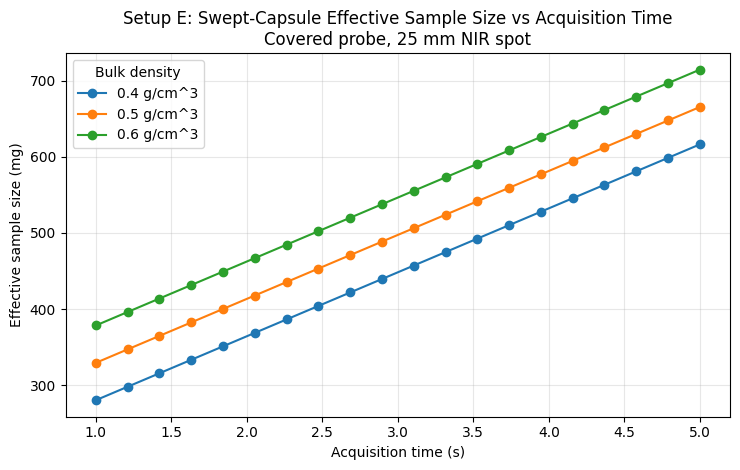

In [10]:
fig_eff_sample_vs_time, ax = plt.subplots(figsize=(7.5, 4.8))
for density, group in df_acq_sorted.groupby("bulk_density_g_per_cm3"):
    ax.plot(group["acquisition_time_s"], group["effective_sample_size_mg"], marker="o", label=f"{density:.1f} g/cm^3")
ax.set_xlabel("Acquisition time (s)")
ax.set_ylabel("Effective sample size (mg)")
ax.set_title("Setup E: Swept-Capsule Effective Sample Size vs Acquisition Time\nCovered probe, 25 mm NIR spot")
ax.grid(True, alpha=0.3)
ax.legend(title="Bulk density")
fig_eff_sample_vs_time.tight_layout()
plt.show()


## Plot 5: Swept-In Incremental Mass vs Acquisition Time by Density

This plot isolates the additional unique mass that enters the NIR beam after acquisition start. It excludes the initial circular spot contribution.


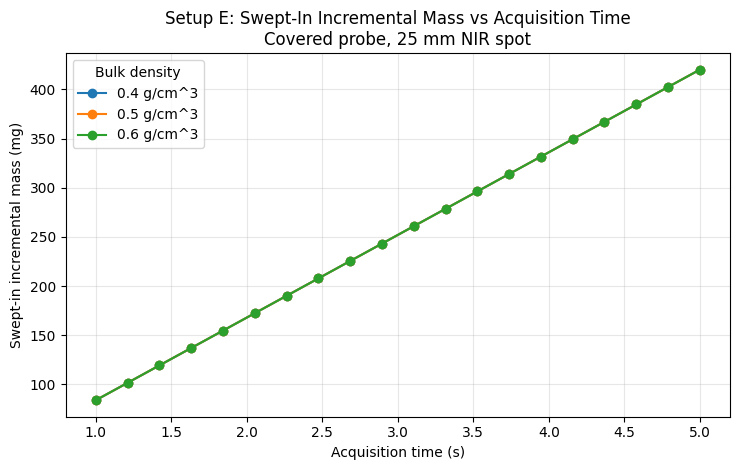

In [11]:
fig_swept_increment_vs_time, ax = plt.subplots(figsize=(7.5, 4.8))
for density, group in df_acq_sorted.groupby("bulk_density_g_per_cm3"):
    ax.plot(group["acquisition_time_s"], group["swept_increment_mass_mg"], marker="o", label=f"{density:.1f} g/cm^3")
ax.set_xlabel("Acquisition time (s)")
ax.set_ylabel("Swept-in incremental mass (mg)")
ax.set_title("Setup E: Swept-In Incremental Mass vs Acquisition Time\nCovered probe, 25 mm NIR spot")
ax.grid(True, alpha=0.3)
ax.legend(title="Bulk density")
fig_swept_increment_vs_time.tight_layout()
plt.show()


## Plot 6: Heatmap - Effective Sample Size for 0.4 g/cm$^3$

This operating map shows how the swept-capsule effective sample size depends jointly on throughput and acquisition time for a bulk density of 0.4 g/cm$^3$.


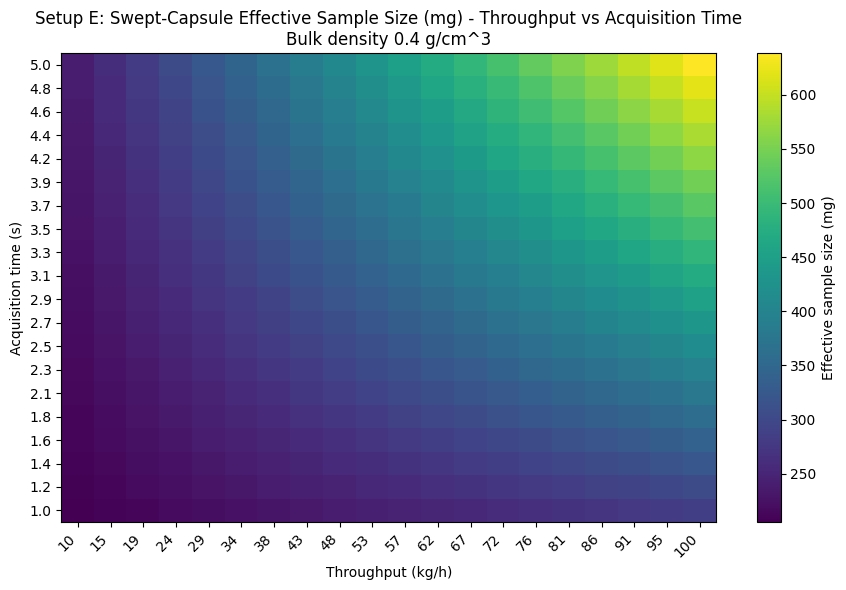

In [12]:
def plot_density_heatmap(dataframe: pd.DataFrame, density: float, figure_title: str):
    filtered = dataframe[dataframe["bulk_density_g_per_cm3"] == density]
    pivot = filtered.pivot_table(
        index="acquisition_time_s",
        columns="throughput_kg",
        values="effective_sample_size_mg",
        aggfunc="mean",
    )

    fig, ax = plt.subplots(figsize=(9, 6))
    image = ax.imshow(pivot.values, aspect="auto", origin="lower")
    ax.set_xticks(np.arange(pivot.shape[1]))
    ax.set_xticklabels([f"{x:.0f}" for x in pivot.columns], rotation=45, ha="right")
    ax.set_yticks(np.arange(pivot.shape[0]))
    ax.set_yticklabels([f"{y:.1f}" for y in pivot.index])
    ax.set_xlabel("Throughput (kg/h)")
    ax.set_ylabel("Acquisition time (s)")
    ax.set_title(figure_title)
    colorbar = fig.colorbar(image, ax=ax)
    colorbar.set_label("Effective sample size (mg)")
    fig.tight_layout()
    return fig, pivot


fig_heatmap_eff_sample_04, pivot_eff_sample_04 = plot_density_heatmap(
    df_3d,
    0.4,
    "Setup E: Swept-Capsule Effective Sample Size (mg) - Throughput vs Acquisition Time\nBulk density 0.4 g/cm^3",
)
plt.show()


## Plot 7: Heatmap - Effective Sample Size for 0.5 g/cm$^3$

This operating map shows how the swept-capsule effective sample size depends jointly on throughput and acquisition time for a bulk density of 0.5 g/cm$^3$.


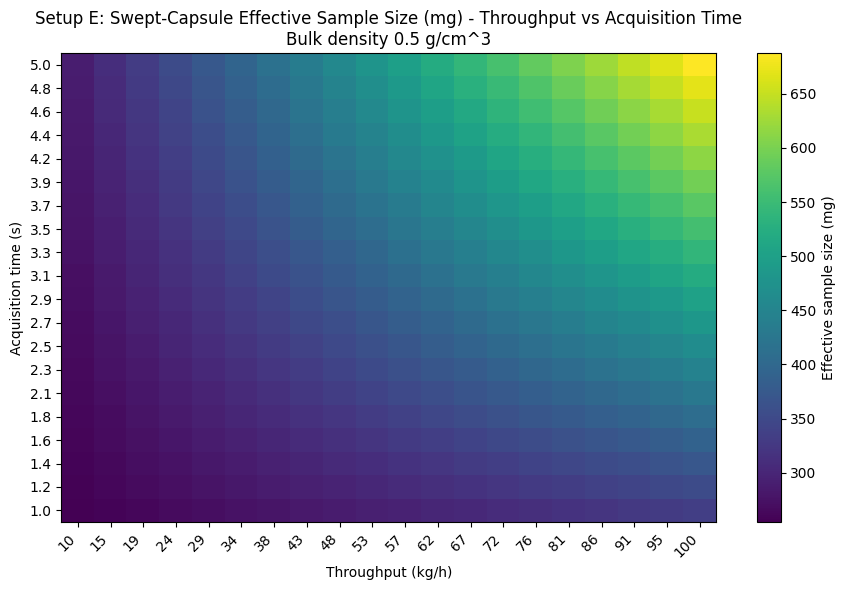

In [13]:
fig_heatmap_eff_sample_05, pivot_eff_sample_05 = plot_density_heatmap(
    df_3d,
    0.5,
    "Setup E: Swept-Capsule Effective Sample Size (mg) - Throughput vs Acquisition Time\nBulk density 0.5 g/cm^3",
)
plt.show()


## Plot 8: Heatmap - Effective Sample Size for 0.6 g/cm$^3$

This operating map shows how the swept-capsule effective sample size depends jointly on throughput and acquisition time for a bulk density of 0.6 g/cm$^3$.


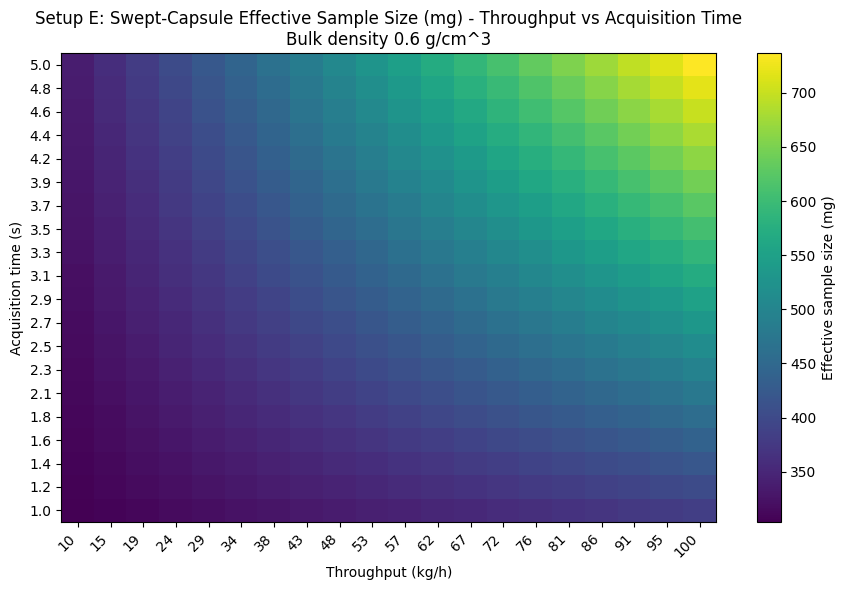

In [14]:
fig_heatmap_eff_sample_06, pivot_eff_sample_06 = plot_density_heatmap(
    df_3d,
    0.6,
    "Setup E: Swept-Capsule Effective Sample Size (mg) - Throughput vs Acquisition Time\nBulk density 0.6 g/cm^3",
)
plt.show()


## Plot 9: Time-Weighted Contribution Proxy vs Acquisition Time

This plot shows the simple future-research time-only proxy, computed as instantaneous illuminated mass multiplied by acquisition time. It is not the primary effective sample size.


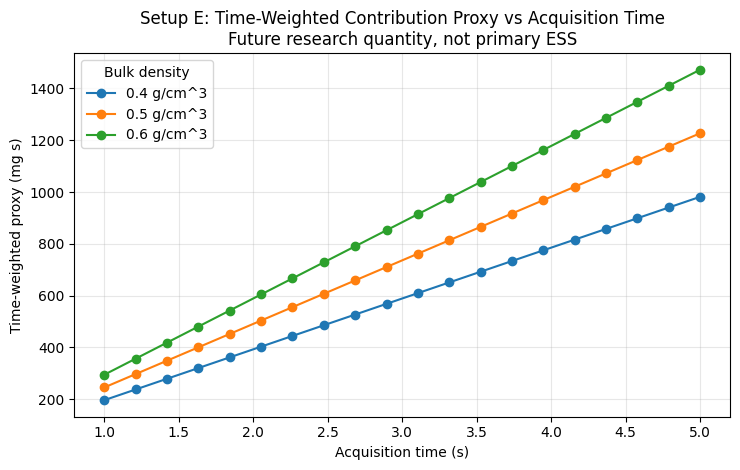

In [15]:
fig_time_weighted_proxy_vs_time, ax = plt.subplots(figsize=(7.5, 4.8))
for density, group in df_acq_sorted.groupby("bulk_density_g_per_cm3"):
    ax.plot(group["acquisition_time_s"], group["time_weighted_contribution_proxy_mg_s"], marker="o", label=f"{density:.1f} g/cm^3")
ax.set_xlabel("Acquisition time (s)")
ax.set_ylabel("Time-weighted proxy (mg s)")
ax.set_title("Setup E: Time-Weighted Contribution Proxy vs Acquisition Time\nFuture research quantity, not primary ESS")
ax.grid(True, alpha=0.3)
ax.legend(title="Bulk density")
fig_time_weighted_proxy_vs_time.tight_layout()
plt.show()


## Schematic: Swept Capsule Geometry

The primary effective sample size is based on the unique material exposed at least once: the initial circular NIR spot plus the swept rectangular increment created by powder advance during acquisition.


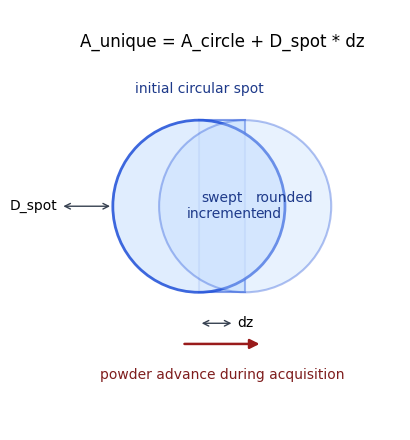

In [16]:
from matplotlib.patches import Circle, Rectangle, FancyArrowPatch

D = base.nir_spot_diameter_cm
r = D / 2.0
dz = base_metrics["advance_dz_cm_per_acq"]

fig_swept_capsule_schematic, ax = plt.subplots(figsize=(8.5, 4.5))
ax.set_aspect("equal")
ax.axis("off")

ax.add_patch(Rectangle((0, -r), dz, D, facecolor="#bfdbfe", edgecolor="#1d4ed8", alpha=0.55, linewidth=1.5))
ax.add_patch(Circle((0, 0), r, facecolor="#dbeafe", edgecolor="#1d4ed8", linewidth=2.0, alpha=0.85))
ax.add_patch(Circle((dz, 0), r, facecolor="#bfdbfe", edgecolor="#1d4ed8", linewidth=1.5, alpha=0.35))

ax.add_patch(FancyArrowPatch((-0.25, -2.0), (dz + 0.25, -2.0), arrowstyle="-|>", mutation_scale=14, linewidth=1.8, color="#991b1b"))
ax.text(dz / 2.0, -2.35, "powder advance during acquisition", ha="center", va="top", color="#7f1d1d")
ax.text(0, r + 0.35, "initial circular spot", ha="center", va="bottom", color="#1e3a8a")
ax.text(dz / 2.0, 0, "swept\nincrement", ha="center", va="center", color="#1e3a8a")
ax.text(dz + 0.15, 0, "rounded\nend", ha="left", va="center", color="#1e3a8a")

ax.annotate("D_spot", xy=(-r, 0), xytext=(-r - 0.8, 0), ha="right", va="center", arrowprops={"arrowstyle": "<->", "color": "#374151"})
ax.annotate("dz", xy=(0, -r - 0.45), xytext=(dz, -r - 0.45), ha="center", va="center", arrowprops={"arrowstyle": "<->", "color": "#374151"})
ax.text(dz / 2.0, r + 1.0, "A_unique = A_circle + D_spot * dz", ha="center", va="bottom", fontsize=12)

pad = max(1.0, r * 0.8)
ax.set_xlim(-r - pad, dz + r + pad)
ax.set_ylim(-r - 2.0, r + 1.6)
fig_swept_capsule_schematic.tight_layout()
plt.show()


## Results Interpretation

- The primary effective sample size now includes all material exposed at least once during acquisition.
- The base case contains the full initial circular spot plus an additional swept-in strip generated by powder motion during the 1 s acquisition.
- Because the 25 mm spot is large relative to the base-case powder advance, the instantaneous component remains a major part of the effective sample size.
- Increasing acquisition time increases effective sample size by elongating the exposed capsule footprint.
- Increasing penetration depth increases instantaneous mass, swept-in incremental mass, and effective sample size linearly.
- Lower bulk density increases powder velocity and the swept increment at fixed throughput, while higher bulk density increases the mass in the initial circular footprint.
- The time-weighted contribution proxy is retained only as a future route toward residence-time and optical-weighting analysis.


## Practical Implications

- Large NIR spots at low powder velocity should not use a refresh-fraction-only effective sample size proxy.
- The starting circular footprint can dominate the effective sample size when powder advance is small relative to spot diameter.
- Acquisition time elongates the exposed footprint rather than simply replacing a fraction of the original spot.
- For Setup E, the swept capsule model better matches the all-unique-exposed-material logic used elsewhere in the project.
- Throughput directly controls powder advance and therefore the incremental swept contribution, but the initial circular contribution remains present for every spectrum.


## Limitations

- probe coverage is assumed guaranteed and is not stress-tested against abnormal operating states
- the rotating outlet valve is not modeled dynamically
- the local velocity near the probe is approximated from throughput and full pipe cross-section
- straight-line translation of powder past the spot is assumed
- velocity is assumed uniform over the NIR spot footprint
- penetration depth is uniform over the full capsule footprint
- residence-time differences across the swept capsule are not included in the primary ESS
- radial and tangential optical intensity gradients are ignored
- penetration depth is swept as an effective parameter, not derived from a wavelength-dependent optical model
- bulk density is treated as spatially uniform and fixed within each scenario
- no particle-level sampling statistics, recirculation, stagnant wall-layer, or repeated-exposure correction is included


## Next Logical Extensions

- replace the top-hat capsule geometry with nonuniform optical intensity weighting
- model local velocity distribution near the side window
- include residence-time weighting over the swept capsule
- couple penetration depth to density and wavelength
- add uncertainty bands for penetration depth, bulk density, and local velocity
- validate the capsule effective sample size proxy against tracer experiments or PAT spectral-response data


## Export and Reporting

This export section writes timestamped CSV, PNG, JSON, and Word outputs into the setup-specific `reports/` folder. The report uses the swept capsule unique-exposure proxy as the primary effective sample size. `python-docx` and `nbformat` are required for Word export with Markdown rendering.


In [17]:
from pathlib import Path
import importlib
import sys

setup_name = "setup_e"
notebook_filename = "setup_E_PATrig_effective_sample_size.ipynb"
report_filename = "setup_e_report.docx"
report_markdown_filename = Path(report_filename).with_suffix(".md").name

notebook_file = globals().get("__vsc_ipynb_file__")
if notebook_file:
    project_root = Path(notebook_file).resolve().parent.parent
else:
    cwd = Path.cwd().resolve()
    if (cwd / "notebooks" / notebook_filename).exists():
        project_root = cwd
    elif cwd.name == "notebooks" and (cwd / notebook_filename).exists():
        project_root = cwd.parent
    else:
        project_root = cwd.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import src.reporting_utils as reporting_utils
reporting_utils = importlib.reload(reporting_utils)

build_structured_word_report_pandoc = reporting_utils.build_structured_word_report_pandoc
create_run_directory = reporting_utils.create_run_directory
dataframe_to_markdown_table = reporting_utils.dataframe_to_markdown_table
save_dataframes_dict = reporting_utils.save_dataframes_dict
save_figures_dict = reporting_utils.save_figures_dict
write_metadata_json = reporting_utils.write_metadata_json

notebook_path = project_root / "notebooks" / notebook_filename

timestamp, run_dir = create_run_directory(project_root, setup_name)

summary_table_df = df_density[[
    "bulk_density_g_per_cm3",
    "velocity_mm_s",
    "acquisition_time_s",
    "advance_dz_mm_per_acq",
    "probe_mass_mg_instant",
    "swept_increment_mass_mg",
    "unique_exposed_mass_mg",
    "effective_sample_size_mg",
    "mass_passed_mg_per_acq",
    "time_weighted_contribution_proxy_mg_s",
]].copy()

penetration_depth_table_df = df_penetration_density[[
    "bulk_density_g_per_cm3",
    "measurement_depth_cm",
    "measurement_depth_mm",
    "velocity_mm_s",
    "advance_dz_mm_per_acq",
    "probe_mass_mg_instant",
    "swept_increment_mass_mg",
    "unique_exposed_mass_mg",
    "effective_sample_size_mg",
]].copy()

acquisition_time_table_df = df_acq_density[[
    "bulk_density_g_per_cm3",
    "acquisition_time_s",
    "velocity_mm_s",
    "advance_dz_mm_per_acq",
    "probe_mass_mg_instant",
    "swept_increment_mass_mg",
    "unique_exposed_mass_mg",
    "effective_sample_size_mg",
    "time_weighted_contribution_proxy_mg_s",
]].copy()

dataframes_to_save = {
    "results_full": results_df,
    "summary_table": summary_table_df,
    "penetration_depth_table": penetration_depth_table_df,
    "acquisition_time_table": acquisition_time_table_df,
    "input_summary": input_summary_df,
}
figures_to_save = {
    "plot_01_instant_swept_unique_vs_penetration_depth": globals().get("fig_instant_swept_unique_vs_depth"),
    "plot_02_effective_sample_size_vs_penetration_depth_by_density": globals().get("fig_eff_sample_vs_depth"),
    "plot_03_powder_advance_vs_acquisition_time": globals().get("fig_advance_vs_time"),
    "plot_04_effective_sample_size_vs_acquisition_time_by_density": globals().get("fig_eff_sample_vs_time"),
    "plot_05_swept_increment_mass_vs_acquisition_time_by_density": globals().get("fig_swept_increment_vs_time"),
    "plot_06_heatmap_effective_sample_size_density_04": globals().get("fig_heatmap_eff_sample_04"),
    "plot_07_heatmap_effective_sample_size_density_05": globals().get("fig_heatmap_eff_sample_05"),
    "plot_08_heatmap_effective_sample_size_density_06": globals().get("fig_heatmap_eff_sample_06"),
    "plot_09_time_weighted_proxy_vs_acquisition_time_by_density": globals().get("fig_time_weighted_proxy_vs_time"),
    "schematic_swept_capsule_geometry": globals().get("fig_swept_capsule_schematic"),
}

csv_files = save_dataframes_dict(dataframes_to_save, run_dir)
png_files = save_figures_dict(figures_to_save, run_dir, dpi=300)

parameter_summary = {
    "Pipe diameter (cm)": base.pipe_diameter_cm,
    "NIR spot diameter (cm)": base.nir_spot_diameter_cm,
    "Base measurement depth (cm)": base.measurement_depth_cm,
    "Measurement depth sweep (mm)": "0.1 to 2.0",
    "Bulk density scenarios (g/cm^3)": ", ".join(f"{density:.1f}" for density in density_scenarios),
    "Base throughput (kg/h)": base.throughput_kg,
    "Acquisition time sweep (s)": "1.0 to 5.0",
    "Throughput sweep (kg/h)": "10 to 100",
    "Primary ESS proxy": "unique exposed swept capsule mass",
}

metadata = {
    "setup_name": setup_name,
    "timestamp": timestamp,
    "notebook_filename": notebook_filename,
    "report_filename": report_filename,
    "report_layout": "structured_scientific_report_pandoc",
    "report_markdown_filename": report_markdown_filename,
    "csv_files": csv_files,
    "png_files": png_files,
    "key_parameters": parameter_summary,
}
write_metadata_json(metadata, run_dir / "metadata.json")

executive_summary_text = (
    "Setup E treats the PAT rig as a covered-probe vertical sampling interface in which powder continuously moves past "
    "a side-window non-contact NIR measurement location. The primary effective sample size is now the unique exposed "
    "optical mass represented by the initial circular 25 mm NIR footprint plus the swept capsule extension created by "
    "powder motion during acquisition. The report also retains instantaneous probed mass, swept-in incremental mass, "
    "mass-passed diagnostics, and a simple time-weighted contribution proxy for future research."
)

worked_example_report_df = baseline_display.rename(columns={"metric": "Quantity", "value": "Value"}).copy()
worked_example_body = (
    "The baseline case reports the center density scenario, base-case penetration depth, powder advance during one acquisition, "
    "instantaneous circular mass, swept-in incremental mass, unique exposed capsule mass, the resulting primary effective sample size, "
    "the transport mass-passed diagnostic, and the future-research time-weighted proxy.\n\n"
    + dataframe_to_markdown_table(worked_example_report_df)
)

parameter_sweep_body = (
    "The Setup E analysis combines a discrete bulk-density comparison with a penetration-depth sweep by density, "
    "an acquisition-time sweep by density, and a throughput-by-acquisition-time sweep by density. The primary response "
    "is the swept-capsule unique exposed mass.\n\n"
    "- bulk density scenarios: 0.4, 0.5, and 0.6 g/cm^3\n"
    "- penetration depth swept from 0.1 to 2.0 mm in 0.1 mm steps for each density\n"
    "- acquisition time swept from 1.0 to 5.0 s for each density\n"
    "- throughput swept from 10 to 100 kg/h for each density\n"
    f"- NIR spot diameter fixed at {base.nir_spot_diameter_cm:.1f} cm\n\n"
    f"This produces {len(results_df)} modeled rows across the density-aware sweeps."
)

density_report_df = summary_table_df.copy()
for column in density_report_df.columns:
    density_report_df[column] = density_report_df[column].map(
        lambda value: f"{value:.4f}" if isinstance(value, (int, float, np.floating)) else value
    )
selected_results_body = (
    "The selected table compares the three bulk-density scenarios at the common base operating condition. "
    "It separates instantaneous circular mass, swept-in incremental mass, unique exposed mass, and the final primary ESS.\n\n"
    + dataframe_to_markdown_table(density_report_df)
)

figure_section_body = (
    "The figures are ordered from the geometric decomposition of effective sample size to penetration-depth trends, "
    "powder-advance behavior, operating maps, the future-research time-weighted proxy, and the capsule schematic."
)
figure_entries = [
    {"filename": "plot_01_instant_swept_unique_vs_penetration_depth.png", "caption": "Figure 1. Instantaneous circular mass, swept-in incremental mass, and unique exposed ESS versus penetration depth for the base density case."},
    {"filename": "plot_02_effective_sample_size_vs_penetration_depth_by_density.png", "caption": "Figure 2. Swept-capsule effective sample size versus penetration depth for bulk densities of 0.4, 0.5, and 0.6 g/cm^3."},
    {"filename": "plot_03_powder_advance_vs_acquisition_time.png", "caption": "Figure 3. Powder advance during acquisition versus acquisition time for the three bulk-density scenarios."},
    {"filename": "plot_04_effective_sample_size_vs_acquisition_time_by_density.png", "caption": "Figure 4. Swept-capsule effective sample size versus acquisition time for the three bulk-density scenarios."},
    {"filename": "plot_05_swept_increment_mass_vs_acquisition_time_by_density.png", "caption": "Figure 5. Swept-in incremental mass versus acquisition time for the three bulk-density scenarios."},
    {"filename": "plot_06_heatmap_effective_sample_size_density_04.png", "caption": "Figure 6. Throughput-acquisition heatmap for swept-capsule effective sample size at 0.4 g/cm^3 bulk density."},
    {"filename": "plot_07_heatmap_effective_sample_size_density_05.png", "caption": "Figure 7. Throughput-acquisition heatmap for swept-capsule effective sample size at 0.5 g/cm^3 bulk density."},
    {"filename": "plot_08_heatmap_effective_sample_size_density_06.png", "caption": "Figure 8. Throughput-acquisition heatmap for swept-capsule effective sample size at 0.6 g/cm^3 bulk density."},
    {"filename": "plot_09_time_weighted_proxy_vs_acquisition_time_by_density.png", "caption": "Figure 9. Time-weighted contribution proxy versus acquisition time, retained as a future-research quantity rather than the primary ESS."},
    {"filename": "schematic_swept_capsule_geometry.png", "caption": "Figure 10. Schematic of the swept capsule geometry used for the primary unique exposed effective sample size proxy."},
]

report_sections = [
    {"source": "notebook", "heading": "## Background"},
    {"source": "notebook", "heading": "## Objective"},
    {"source": "notebook", "heading": "## Theory"},
    {"source": "notebook", "heading": "## Interpreting Density, Velocity, and Throughput"},
    {"source": "notebook", "heading": "## Three Sampling Quantities Used in This Notebook"},
    {"source": "notebook", "heading": "## Assumptions"},
    {"source": "notebook", "heading": "## Compute Sampling Metrics"},
    {"source": "content", "heading": "Worked example", "body": worked_example_body},
    {"source": "content", "heading": "Model scenarios and sweep design", "body": parameter_sweep_body},
    {"source": "content", "heading": "Selected results table", "body": selected_results_body},
    {"source": "content", "heading": "Figures", "body": figure_section_body, "figures": figure_entries},
    {"source": "notebook", "heading": "## Results Interpretation"},
    {"source": "notebook", "heading": "## Practical Implications"},
    {"source": "notebook", "heading": "## Limitations"},
]
appendix_sections = [
    {"source": "notebook", "heading": "## Next Logical Extensions"},
]

word_report_path = build_structured_word_report_pandoc(
    report_title="Setup E PAT Rig Swept-Capsule Effective Sample Size Report",
    setup_name=setup_name,
    timestamp=timestamp,
    run_dir=run_dir,
    notebook_path=notebook_path,
    output_filename=report_filename,
    executive_summary_text=executive_summary_text,
    parameter_summary=parameter_summary,
    report_sections=report_sections,
    appendix_sections=appendix_sections,
    csv_filenames=csv_files,
    figure_filenames=png_files,
    markdown_filename=report_markdown_filename,
)

print(f"Report run directory: {run_dir}")
print(f"CSV files: {csv_files}")
print(f"PNG files: {png_files}")
print(f"Markdown report source: {run_dir / report_markdown_filename}")
print(f"Word report: {word_report_path}")


Report run directory: C:\temp files\EFS\reports\setup_e\20260422_115431
CSV files: ['results_full.csv', 'summary_table.csv', 'penetration_depth_table.csv', 'acquisition_time_table.csv', 'input_summary.csv']
PNG files: ['plot_01_instant_swept_unique_vs_penetration_depth.png', 'plot_02_effective_sample_size_vs_penetration_depth_by_density.png', 'plot_03_powder_advance_vs_acquisition_time.png', 'plot_04_effective_sample_size_vs_acquisition_time_by_density.png', 'plot_05_swept_increment_mass_vs_acquisition_time_by_density.png', 'plot_06_heatmap_effective_sample_size_density_04.png', 'plot_07_heatmap_effective_sample_size_density_05.png', 'plot_08_heatmap_effective_sample_size_density_06.png', 'plot_09_time_weighted_proxy_vs_acquisition_time_by_density.png', 'schematic_swept_capsule_geometry.png']
Markdown report source: C:\temp files\EFS\reports\setup_e\20260422_115431\setup_e_report.md
Word report: C:\temp files\EFS\reports\setup_e\20260422_115431\setup_e_report.docx
